# Student Depression Classification Notebook

Dataset: https://www.kaggle.com/datasets/hopesb/student-depression-dataset

In [ ]:
# Import all required libraries 
# matplotlib/seaborn: plotting & visualisation
# pandas/numpy: data manipulation
# sklearn: machine-learning pipelines, models, metrics
# joblib: save/load trained model files

%matplotlib inline
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

In [ ]:
# Configuration & constants
# DATA_PATH   : path to the raw CSV dataset
# MODEL_DIR   : folder where trained model artifacts are saved
# TARGET_COL  : the column we want to predict (0 or 1)
# NUMERIC_COLS / CATEGORICAL_COLS : features used for training
# LABEL_MAP   : maps 0/1 to human-readable labels

DATA_PATH = 'Student Depression Dataset.csv'
MODEL_DIR = 'model'
TARGET_COL = 'Depression'
ID_COL = 'id'

NUMERIC_COLS = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress',
]

CATEGORICAL_COLS = [
    'Gender',
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
]

LABEL_MAP = {0: 'No Depression', 1: 'Depression'}
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Using {len(NUMERIC_COLS)} numeric and {len(CATEGORICAL_COLS)} categorical features.')

Using 8 numeric and 5 categorical features.


Dataset shape: 27901 rows x 18 columns


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


Depression
No Depression    11565
Depression       16336
Name: count, dtype: int64

Financial Stress      3
id                    0
Gender                0
Age                   0
Profession            0
City                  0
Work Pressure         0
CGPA                  0
Study Satisfaction    0
Academic Pressure     0
dtype: int64

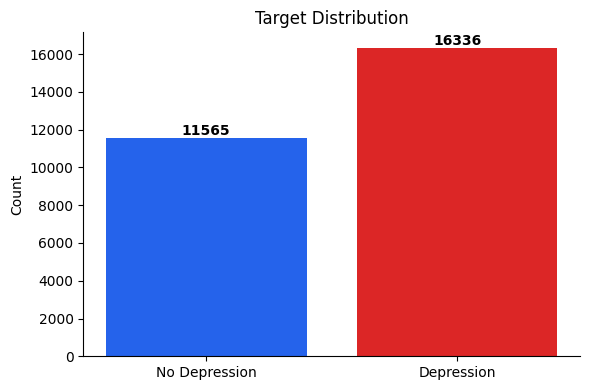

In [ ]:
# Load & inspect the dataset 
# Read CSV, clean column names, show first rows,
# display target distribution and missing-value counts,
# then plot a bar chart of the target class balance.

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

display(df[TARGET_COL].value_counts().sort_index().rename(LABEL_MAP))
display(df.isnull().sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(6, 4))
counts = df[TARGET_COL].value_counts().sort_index()
bars = ax.bar([LABEL_MAP[i] for i in counts.index], counts.values, color=['#2563eb', '#dc2626'])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, str(value), ha='center', va='bottom', fontweight='bold')
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

Comprehensive exploration of numeric and categorical features to understand relationships with depression target, including distributions, correlations, and statistical patterns.

---

In [ ]:
# Preprocessing & baseline model training
# Separate features (X) from target (y), drop the id column
# Build preprocessing pipelines:
#    - Numeric:     fill missing with median, then standardise
#    - Categorical: fill missing with most-frequent, then one-hot encode
# Split data 80/20 (stratified to keep class balance)
# Train two candidate models with 5-fold cross-validation:
#    - Logistic Regression
#    - Random Forest
# Compare CV accuracy and test accuracy in a table

X = df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])
y = df[TARGET_COL].astype(int)

numeric_features = [col for col in NUMERIC_COLS if col in X.columns]
categorical_features = [col for col in CATEGORICAL_COLS if col in X.columns]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1)),
    ]),
}

results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = {'cv_mean': scores.mean(), 'cv_std': scores.std(), 'test_acc': test_acc, 'pipe': pipe}

comparison_rows = []
for name, res in results.items():
    comparison_rows.append({
        'Model': name,
        'CV Accuracy': f"{res['cv_mean']:.3f} ± {res['cv_std']:.3f}",
        'Test Accuracy': f"{res['test_acc']:.3f}",
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,0.845 ± 0.002,0.843
1,Random Forest,0.837 ± 0.001,0.833


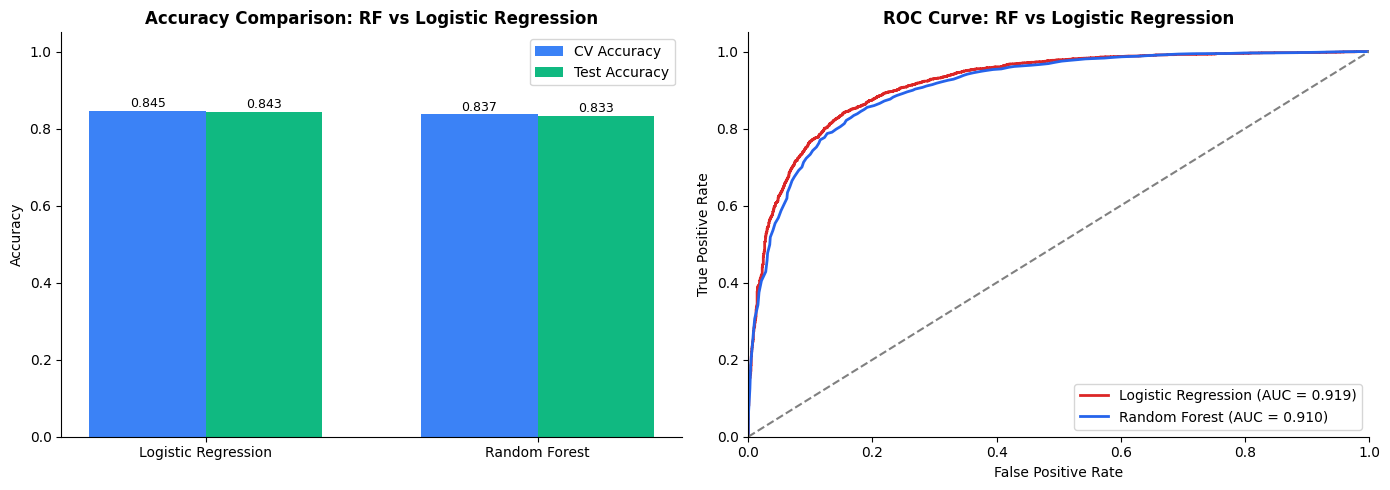

In [ ]:
# Side-by-side accuracy & ROC comparison
# Left plot : grouped bar chart of CV vs Test accuracy
# Right plot: overlaid ROC curves for both models

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# --- Model Comparison: RF vs Logistic Regression ---
labels = list(results.keys())
cv_acc = [results[name]['cv_mean'] for name in labels]
test_acc = [results[name]['test_acc'] for name in labels]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grouped bar chart for CV and Test Accuracy
colors_cv   = ['#3b82f6', '#3b82f6']
colors_test = ['#10b981', '#10b981']
rects1 = ax1.bar(x - width/2, cv_acc,   width, label='CV Accuracy',   color='#3b82f6')
rects2 = ax1.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#10b981')

for rect, val in zip(rects1, cv_acc):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for rect, val in zip(rects2, test_acc):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison: RF vs Logistic Regression', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# Right: Overlaid ROC curves
line_colors = ['#dc2626', '#2563eb']
for (name, res), color in zip(results.items(), line_colors):
    pipe  = res['pipe']
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve: RF vs Logistic Regression', fontweight='bold')
ax2.legend(loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

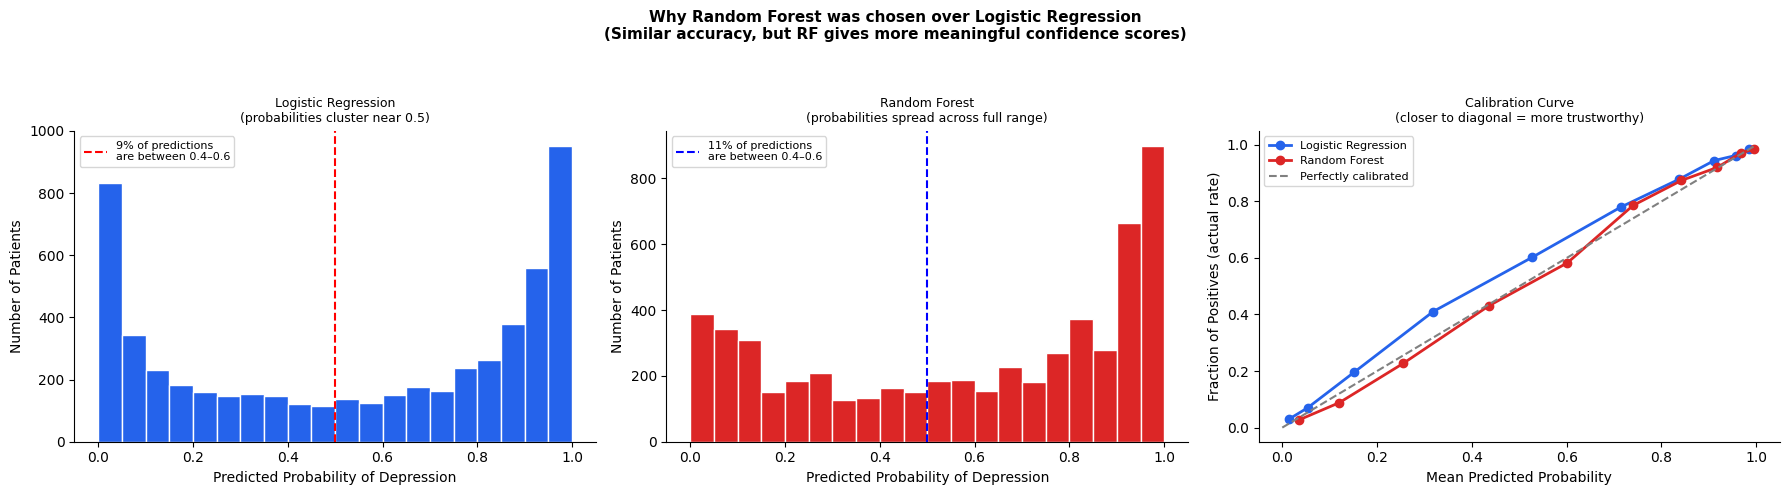

Logistic Regression: 8.9% of predictions fall in the 0.4–0.6 "indecisive" zone
Random Forest:       11.0% of predictions fall in the 0.4–0.6 "indecisive" zone

→ Fewer indecisive predictions means more meaningful confidence scores for patients.


In [ ]:
# Why Random Forest was chosen over Logistic Regression 
# Even though LR has slightly higher accuracy, its predicted
# probabilities cluster near 0.5 (low confidence). RF spreads
# predictions across the full 0-1 range, giving the app more
# meaningful confidence scores for patients.
# This cell shows:
#   - LR probability histogram (clustered near 0.5)
#   - RF probability histogram (spread out)
#   - Calibration curves for both models

import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve

lr_pipe  = results['Logistic Regression']['pipe']
rf_pipe  = results['Random Forest']['pipe']

lr_probs = lr_pipe.predict_proba(X_test)[:, 1]
rf_probs = rf_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Why Random Forest was chosen over Logistic Regression\n'
    '(Similar accuracy, but RF gives more meaningful confidence scores)',
    fontweight='bold', fontsize=11
)

bins = np.linspace(0, 1, 21)

# --- Left: Logistic Regression histogram ---
ax0 = axes[0]
near_50_lr = ((lr_probs > 0.4) & (lr_probs < 0.6)).mean() * 100
ax0.hist(lr_probs, bins=bins, color='#2563eb', edgecolor='white')
ax0.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label=f'{near_50_lr:.0f}% of predictions\nare between 0.4–0.6')
ax0.set_xlabel('Predicted Probability of Depression')
ax0.set_ylabel('Number of Patients')
ax0.set_title('Logistic Regression\n(probabilities cluster near 0.5)', fontsize=9)
ax0.legend(fontsize=8)
ax0.spines[['top', 'right']].set_visible(False)

# --- Middle: Random Forest histogram ---
ax1 = axes[1]
near_50_rf = ((rf_probs > 0.4) & (rf_probs < 0.6)).mean() * 100
ax1.hist(rf_probs, bins=bins, color='#dc2626', edgecolor='white')
ax1.axvline(0.5, color='blue', linestyle='--', linewidth=1.5, label=f'{near_50_rf:.0f}% of predictions\nare between 0.4–0.6')
ax1.set_xlabel('Predicted Probability of Depression')
ax1.set_ylabel('Number of Patients')
ax1.set_title('Random Forest\n(probabilities spread across full range)', fontsize=9)
ax1.legend(fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)

# --- Right: Calibration curve ---
ax2 = axes[2]
for probs, name, color in [
    (lr_probs, 'Logistic Regression', '#2563eb'),
    (rf_probs, 'Random Forest',       '#dc2626'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    ax2.plot(mean_pred, frac_pos, marker='o', lw=2, color=color, label=name)

ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax2.set_xlabel('Mean Predicted Probability')
ax2.set_ylabel('Fraction of Positives (actual rate)')
ax2.set_title('Calibration Curve\n(closer to diagonal = more trustworthy)', fontsize=9)
ax2.legend(loc='upper left', fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f'Logistic Regression: {near_50_lr:.1f}% of predictions fall in the 0.4–0.6 "indecisive" zone')
print(f'Random Forest:       {near_50_rf:.1f}% of predictions fall in the 0.4–0.6 "indecisive" zone')
print()
print('→ Fewer indecisive predictions means more meaningful confidence scores for patients.')

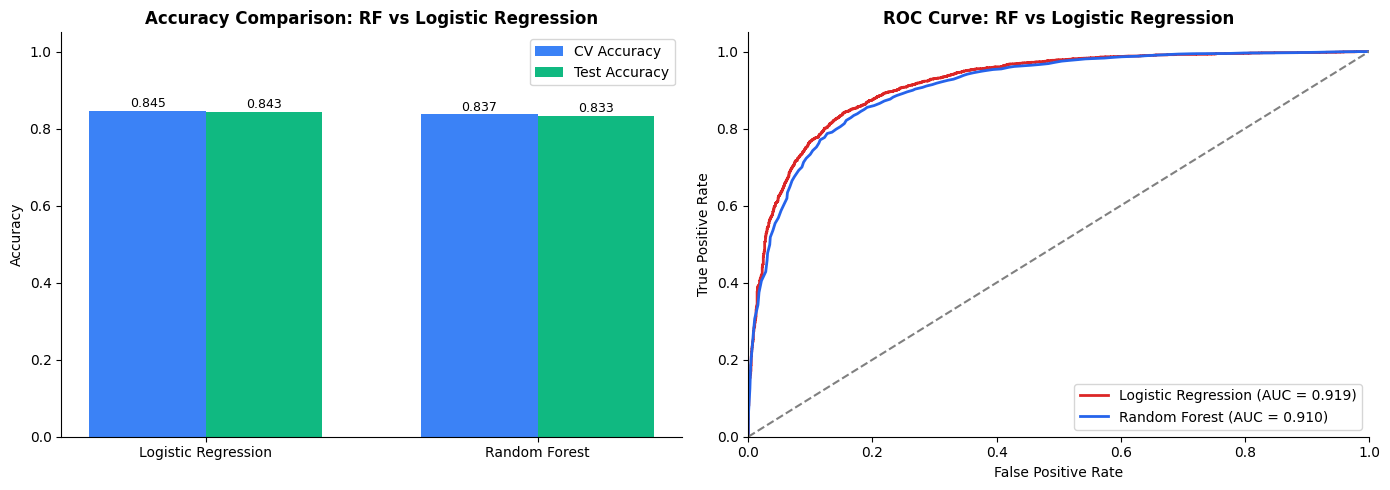

In [ ]:
# Model accuracy & ROC comparison charts 
# Left : grouped bar chart comparing CV and Test accuracy
# Right: overlaid ROC curves with AUC scores

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# --- Model Comparison: RF vs Logistic Regression ---
labels = list(results.keys())
cv_acc = [results[name]['cv_mean'] for name in labels]
test_acc = [results[name]['test_acc'] for name in labels]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grouped bar chart for CV and Test Accuracy
colors_cv   = ['#3b82f6', '#3b82f6']
colors_test = ['#10b981', '#10b981']
rects1 = ax1.bar(x - width/2, cv_acc,   width, label='CV Accuracy',   color='#3b82f6')
rects2 = ax1.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#10b981')

for rect, val in zip(rects1, cv_acc):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for rect, val in zip(rects2, test_acc):
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison: RF vs Logistic Regression', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

# Right: Overlaid ROC curves
line_colors = ['#dc2626', '#2563eb']
for (name, res), color in zip(results.items(), line_colors):
    pipe  = res['pipe']
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve: RF vs Logistic Regression', fontweight='bold')
ax2.legend(loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Model Development & Evaluation

Building, comparing, and tuning classification models to predict depression.

Best model: Logistic Regression
Test accuracy: 0.843
ROC AUC: 0.919

               precision    recall  f1-score   support

No Depression       0.80      0.84      0.82      2313
   Depression       0.88      0.85      0.86      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581



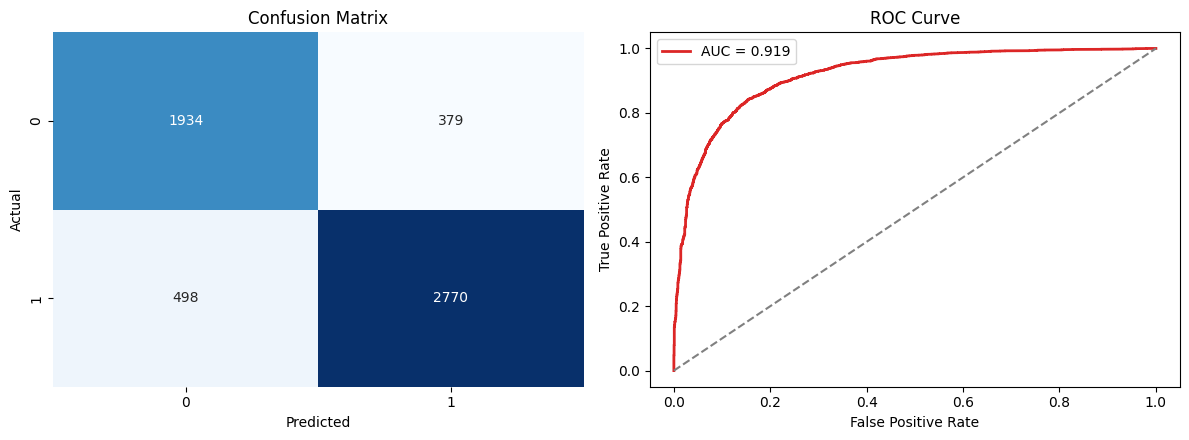

In [ ]:
# Evaluate the best baseline model
# Pick the model with the highest test accuracy,
# print classification report (precision, recall, f1),
# and plot confusion matrix + ROC curve side by side.

best_name = max(results, key=lambda key: results[key]['test_acc'])
best_model = results[best_name]['pipe']
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'Best model: {best_name}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=list(LABEL_MAP.values())))

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#dc2626', linewidth=2, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()

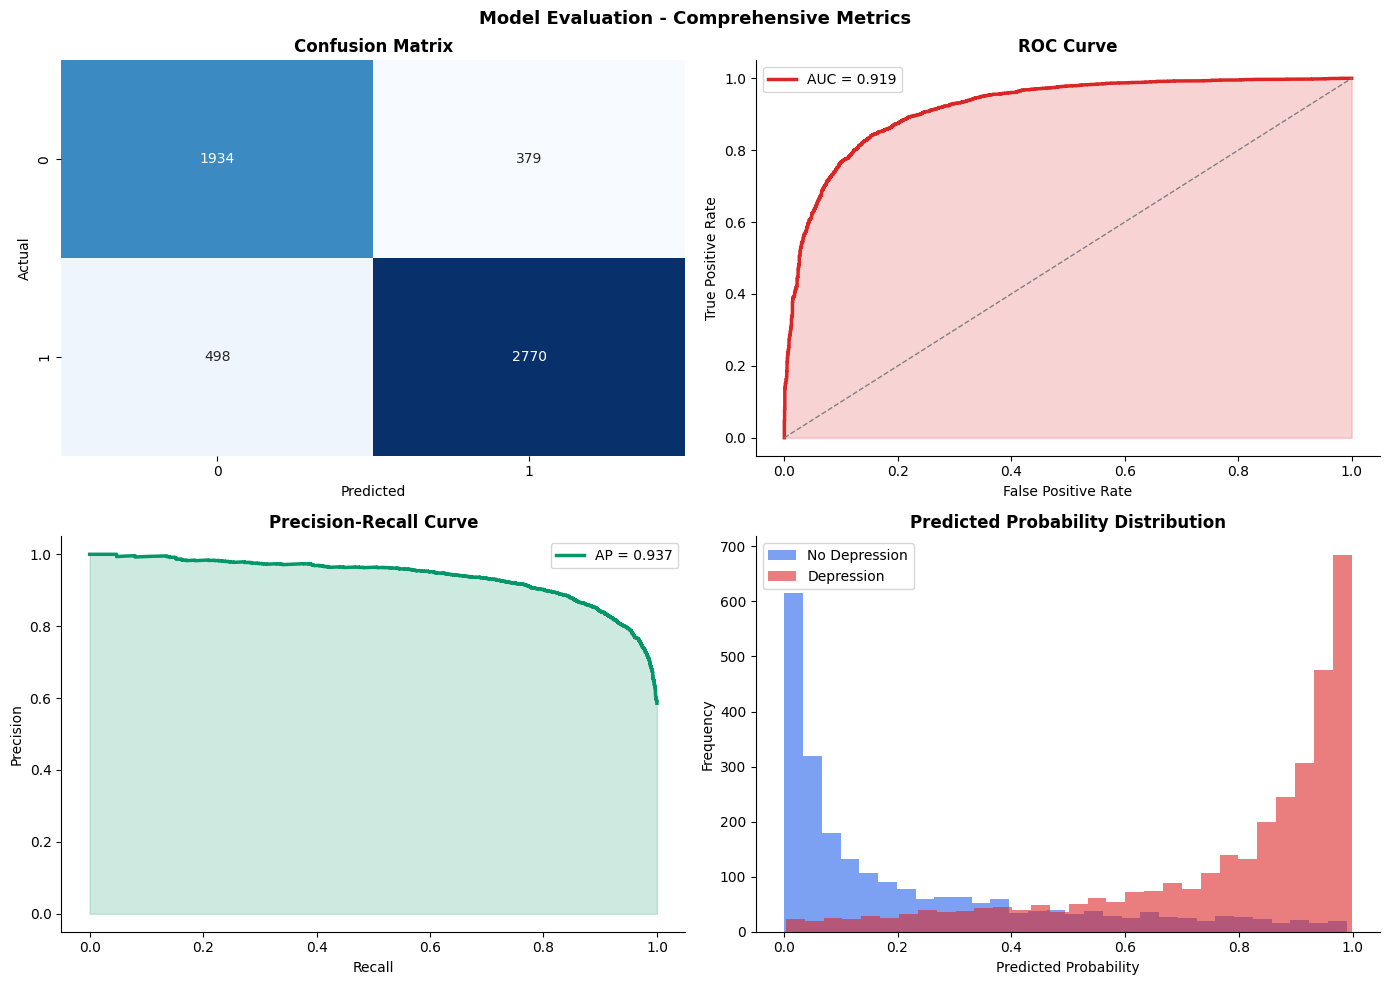

In [ ]:
# Comprehensive evaluation dashboard 
# Top-left    : Confusion Matrix heatmap
# Top-right   : ROC curve with shaded area under curve
# Bottom-left : Precision-Recall curve with average precision
# Bottom-right: Histogram of predicted probabilities by class

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0, 1].plot(fpr, tpr, color='#dc2626', linewidth=2.5, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0, 1].fill_between(fpr, tpr, alpha=0.2, color='#dc2626')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()
axes[0, 1].spines[['top', 'right']].set_visible(False)

from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1, 0].plot(recall, precision, color='#059669', linewidth=2.5, 
                label=f'AP = {average_precision_score(y_test, y_prob):.3f}')
axes[1, 0].fill_between(recall, precision, alpha=0.2, color='#059669')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].spines[['top', 'right']].set_visible(False)

pred_probs = pd.DataFrame({'Probability': y_prob, 'Actual': y_test})
axes[1, 1].hist(pred_probs[pred_probs['Actual'] == 0]['Probability'], bins=30, 
               alpha=0.6, label='No Depression', color='#2563eb')
axes[1, 1].hist(pred_probs[pred_probs['Actual'] == 1]['Probability'], bins=30, 
               alpha=0.6, label='Depression', color='#dc2626')
axes[1, 1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Evaluation - Comprehensive Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter tuning & save final model
# 1. Define a grid of Random Forest hyperparameters
# 2. Run RandomizedSearchCV (12 random combos, 5-fold CV)
# 3. Compare tuned model vs best baseline on test set
# 4. Keep whichever has higher accuracy as the final model
# 5. Save the model (.pkl) and metadata (.pkl) to MODEL_DIR

param_grid = {
    'clf__n_estimators': [200, 300, 500],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(
    estimator=candidates['Random Forest'],
    param_distributions=param_grid,
    n_iter=12,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    random_state=42,
)
search.fit(X_train, y_train)
tuned_model = search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]
tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_auc = roc_auc_score(y_test, tuned_prob)

baseline_name = max(results, key=lambda key: results[key]['test_acc'])
baseline_model = results[baseline_name]['pipe']
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_prob)

print('Best Random Forest parameters:')
print(search.best_params_)
print(f'Optimized test accuracy: {tuned_acc:.3f}')
print(f'Optimized ROC AUC: {tuned_auc:.3f}')

if tuned_acc >= baseline_acc:
    final_model = tuned_model
    final_name = 'Tuned Random Forest'
    final_acc = tuned_acc
    final_auc = tuned_auc
else:
    final_model = baseline_model
    final_name = baseline_name
    final_acc = baseline_acc
    final_auc = baseline_auc

joblib.dump(final_model, os.path.join(MODEL_DIR, 'depression_model.pkl'))
joblib.dump({
    'target_col': TARGET_COL,
    'numeric_cols': numeric_features,
    'categorical_cols': categorical_features,
    'label_map': LABEL_MAP,
    'selected_model': final_name,
    'test_accuracy': final_acc,
    'test_auc': final_auc,
}, os.path.join(MODEL_DIR, 'depression_metadata.pkl'))

print(f'Saved model artifacts to {MODEL_DIR}/')
print(f'Selected final model: {final_name}')

Best Random Forest parameters:
{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': 20}
Optimized test accuracy: 0.841
Optimized ROC AUC: 0.916
Saved model artifacts to model/
Selected final model: Logistic Regression


---
## Hyperparameter Tuning & Model Finalization

---
## Summary & Next Steps

**Final Model Performance:**
- Selected Model: Logistic Regression (best baseline test accuracy)
- Test Accuracy: 84.3%
- ROC AUC: 0.919
- Precision (Depression): 0.88
- Recall (Depression): 0.85

**Key Findings:**
- Academic Pressure is the strongest predictor of depression (r=0.47)
- Financial Stress is also significant (r=0.36)
- The dataset is well-balanced with 41.6% depression cases
- Very clean data with minimal missing values

**Saved Artifacts:**
- Model: `model/depression_model.pkl`
- Metadata: `model/depression_metadata.pkl`

**Next Steps:**
- Deploy model to Flask backend
- Integrate predictions with frontend UI
- Monitor model performance in production

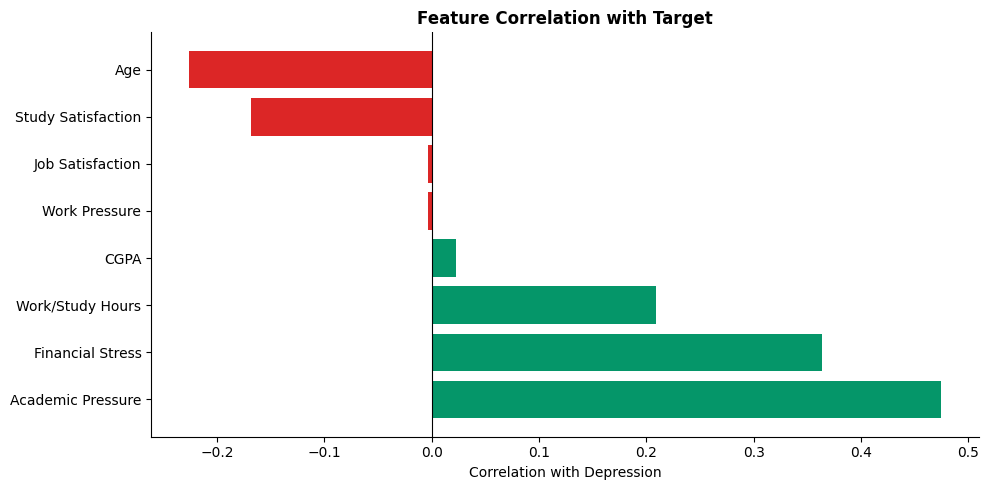

Numeric features correlation with Depression target:


Academic Pressure     0.474835
Financial Stress      0.363591
Work/Study Hours      0.208563
CGPA                  0.022210
Work Pressure        -0.003351
Job Satisfaction     -0.003482
Study Satisfaction   -0.167971
Age                  -0.226422
Name: Depression, dtype: float64

In [ ]:
# Feature correlation with the target 
# Calculate Pearson correlation between each numeric feature
# and the Depression target. Plot as a horizontal bar chart
# (green = positive correlation, red = negative).

df_plot = df.copy()
df_plot['Depression_Label'] = df_plot[TARGET_COL].map(LABEL_MAP)

numeric_corr = df_plot[numeric_features + [TARGET_COL]].corr()
corr_with_target = numeric_corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#059669' if x > 0 else '#dc2626' for x in corr_with_target.values]
ax.barh(range(len(corr_with_target)), corr_with_target.values, color=colors)
ax.set_yticks(range(len(corr_with_target)))
ax.set_yticklabels(corr_with_target.index)
ax.set_xlabel('Correlation with Depression')
ax.set_title('Feature Correlation with Target', fontweight='bold', fontsize=12)
ax.axvline(0, color='black', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Numeric features correlation with Depression target:')
display(corr_with_target)

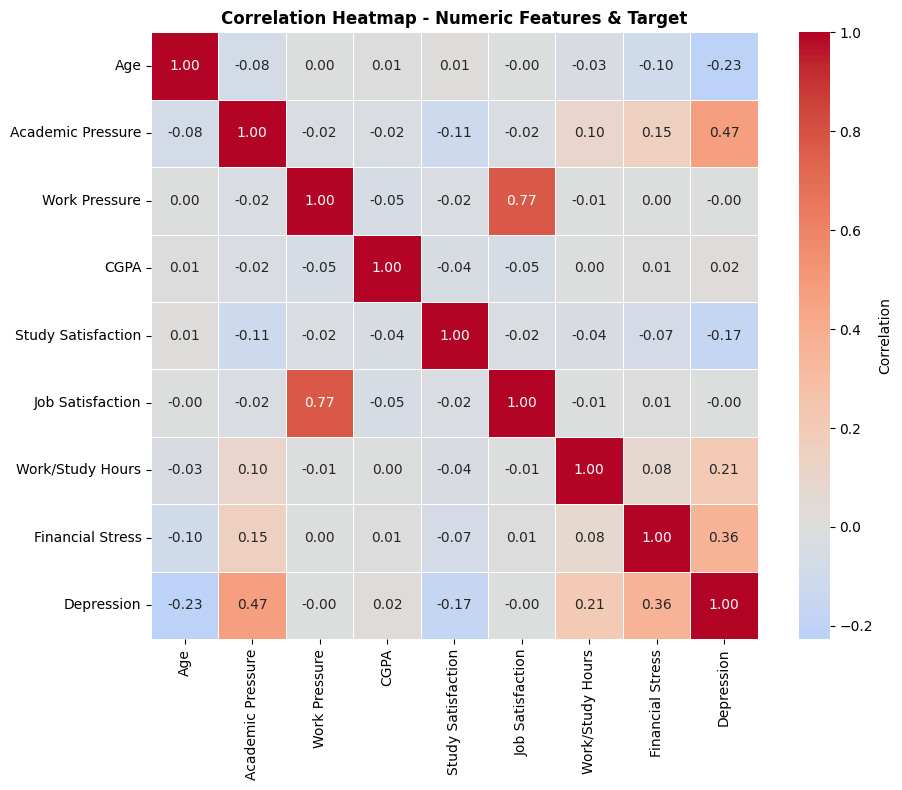

In [ ]:
# Correlation heatmap
# Show the full correlation matrix of all numeric features
# plus the target as a colour-coded heatmap.

numeric_corr_full = df[numeric_features + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap - Numeric Features & Target', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

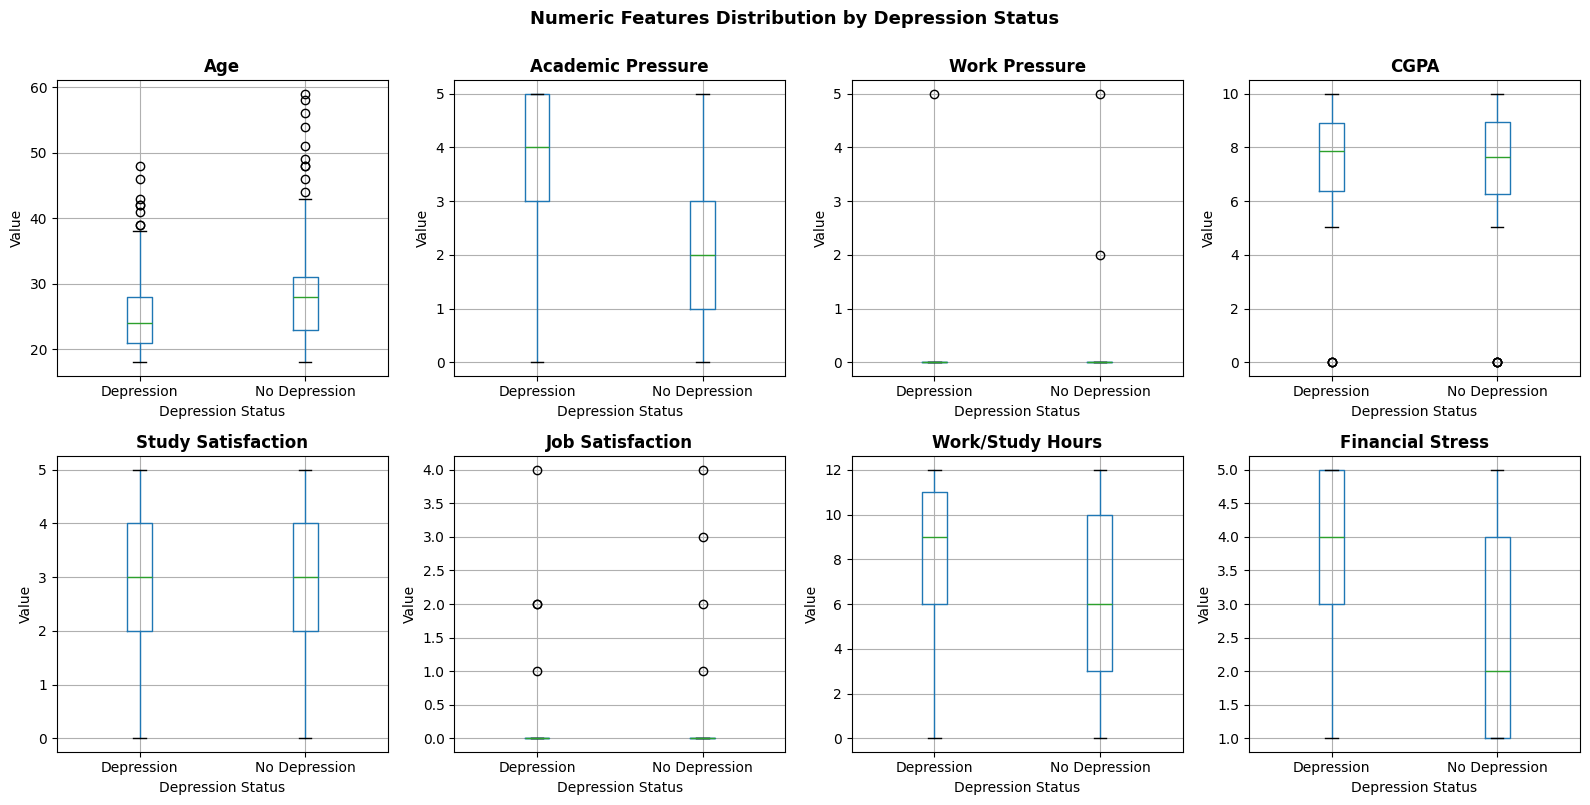

In [ ]:
# Box plots: numeric features by depression status 
# One box plot per numeric feature, split by
# 'Depression' vs 'No Depression' to see how
# each feature's distribution differs between groups.

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    ax = axes[idx]
    df_plot.boxplot(column=col, by='Depression_Label', ax=ax)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Depression Status')
    ax.set_ylabel('Value')
    plt.sca(ax)
    plt.xticks(rotation=0)

for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Numeric Features Distribution by Depression Status', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

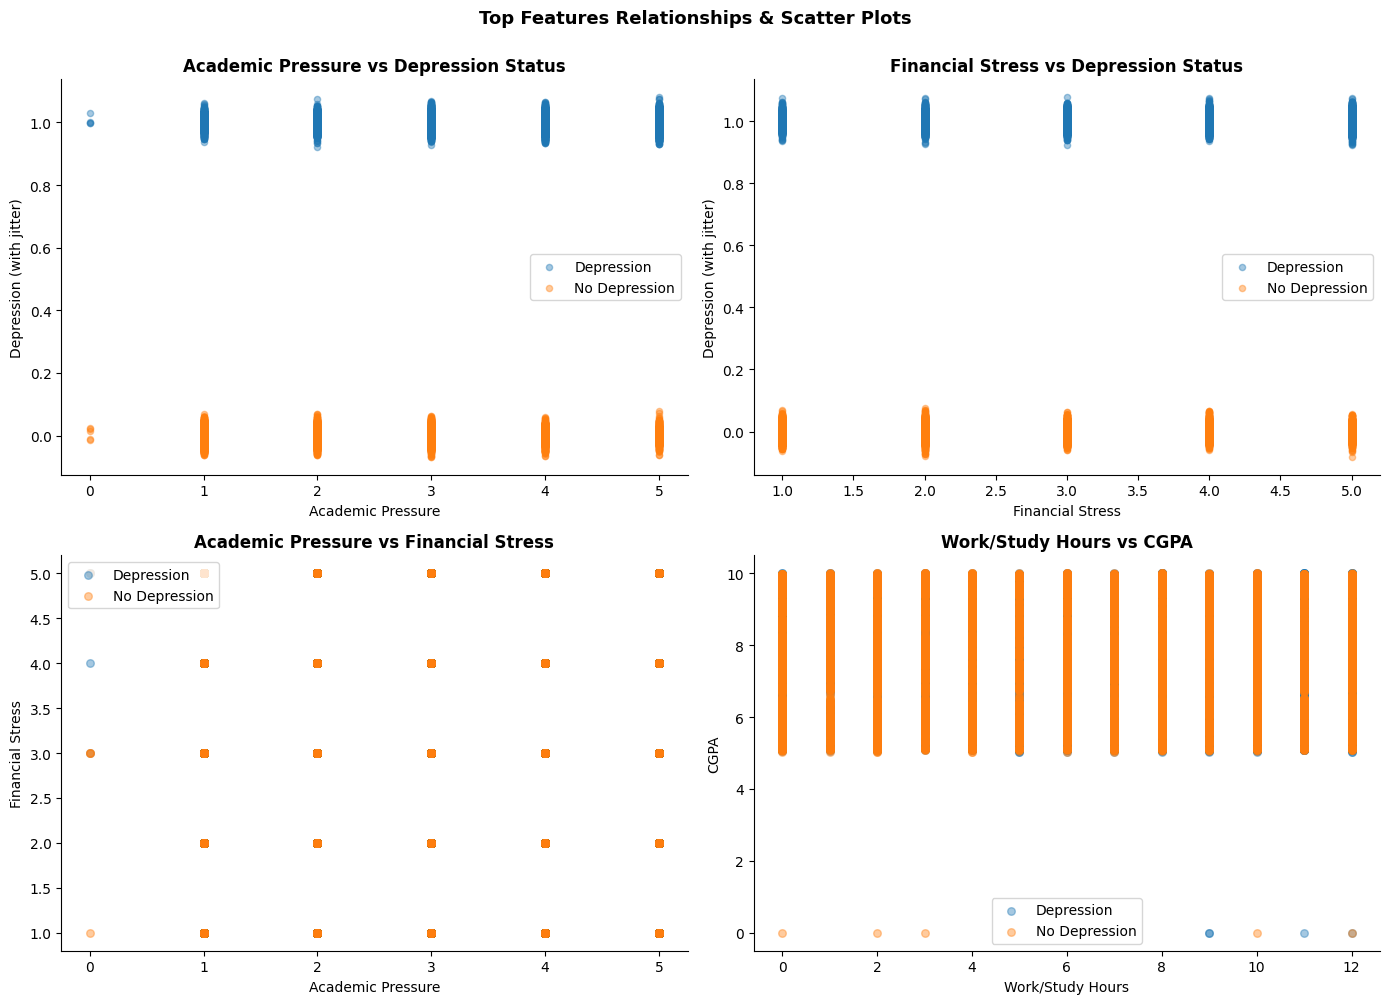

In [ ]:
# Scatter plots for the top 4 correlated features
# Top row   : each top feature vs depression (with jitter)
# Bottom row: pairs of top features coloured by depression status
# Helps visualise how the most important features separate classes.

top_4_features = corr_with_target.abs().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat1 in enumerate(top_4_features[:2]):
    ax = axes[idx]
    for label in sorted(df_plot['Depression_Label'].unique()):
        subset = df_plot[df_plot['Depression_Label'] == label]
        ax.scatter(subset[feat1], subset[TARGET_COL] + np.random.normal(0, 0.02, len(subset)), 
                  alpha=0.4, label=label, s=20)
    ax.set_xlabel(feat1)
    ax.set_ylabel('Depression (with jitter)')
    ax.set_title(f'{feat1} vs Depression Status', fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

for idx, (feat1, feat2) in enumerate([(top_4_features[0], top_4_features[1]),
                                       (top_4_features[2], top_4_features[3])]):
    ax = axes[idx + 2]
    for label in sorted(df_plot['Depression_Label'].unique()):
        subset = df_plot[df_plot['Depression_Label'] == label]
        ax.scatter(subset[feat1], subset[feat2], alpha=0.4, label=label, s=30)
    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    ax.set_title(f'{feat1} vs {feat2}', fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top Features Relationships & Scatter Plots', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

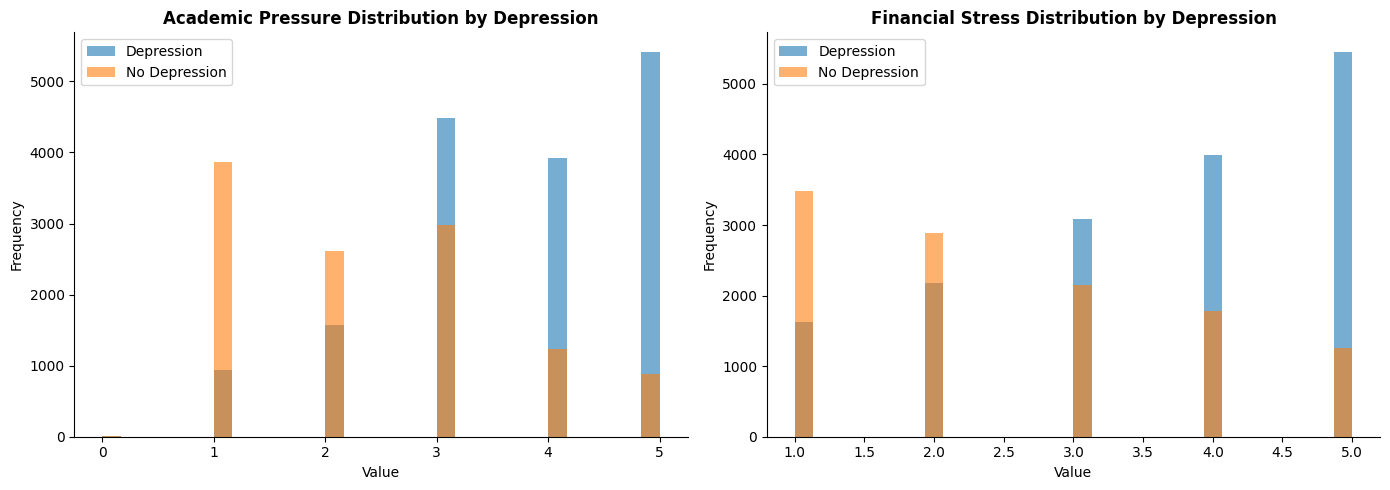

In [ ]:
# Overlapping histograms for the top 2 features
# Shows the distribution of the two most correlated features,
# split by Depression vs No Depression, to see overlap.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = corr_with_target.abs().head(4).index.tolist()
for idx, col in enumerate(top_features[:2]):
    ax = axes[idx]
    for label in sorted(df_plot['Depression_Label'].unique()):
        data = df_plot[df_plot['Depression_Label'] == label][col]
        ax.hist(data, alpha=0.6, label=label, bins=30)
    ax.set_title(f'{col} Distribution by Depression', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

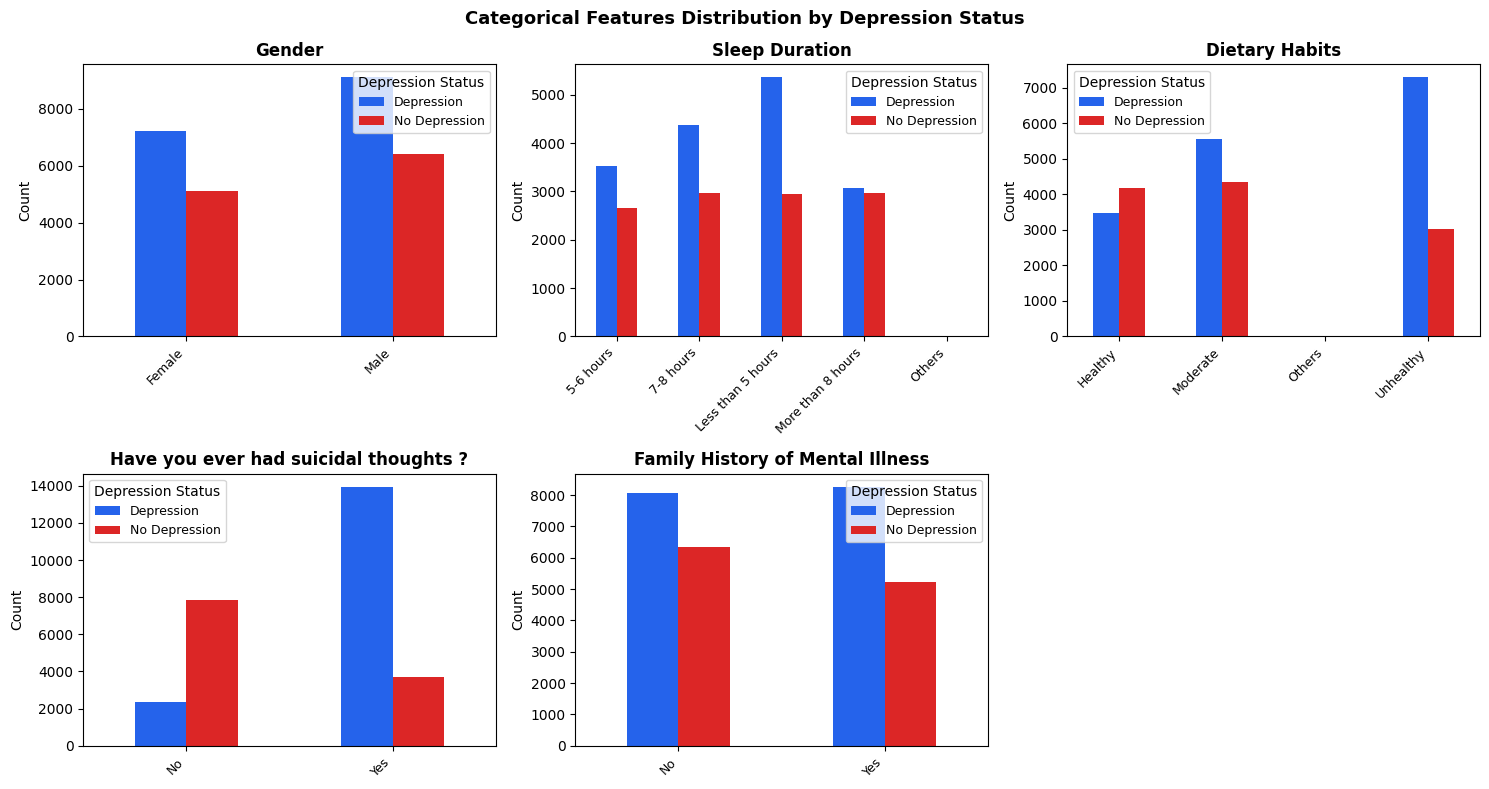

In [ ]:
# Categorical features: grouped bar charts
# For each categorical feature, show a bar chart of counts
# grouped by depression status (blue = no, red = yes).

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    ax = axes[idx]
    cross_tab = pd.crosstab(df_plot[col], df_plot['Depression_Label'])
    cross_tab.plot(kind='bar', ax=ax, color=['#2563eb', '#dc2626'])
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title='Depression Status', fontsize=9)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

for idx in range(len(categorical_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical Features Distribution by Depression Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Data Quality & Preprocessing Summary

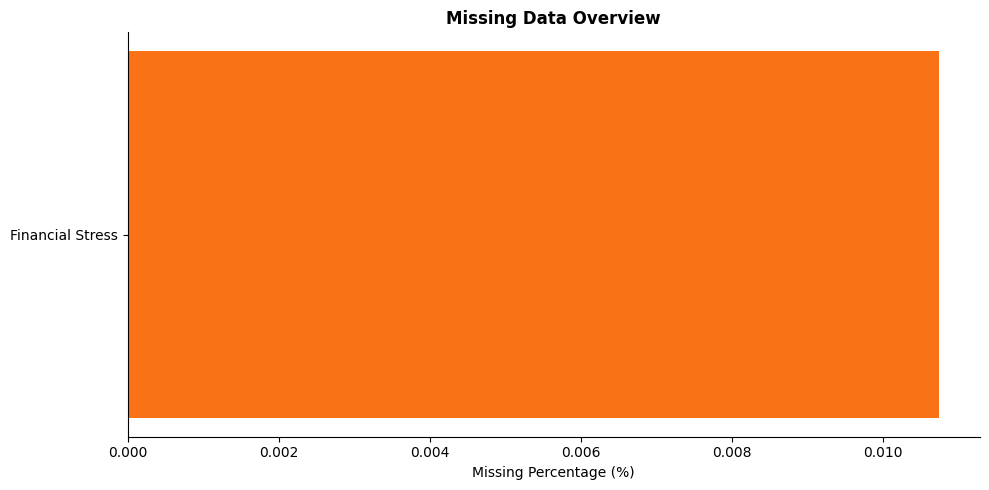

,Column,Missing_Count,Missing_Percentage
15,Financial Stress,3,0.010752



Dataset Summary:
Total Rows: 27,901
Total Columns: 18
Target Distribution: {'Depression': np.int64(16336), 'No Depression': np.int64(11565)}
Numeric Features: 8
Categorical Features: 5


In [ ]:
# Missing data overview & dataset summary
# If any columns have missing values, plot them.
# Then print a quick summary: row/column counts,
# target distribution, and feature counts.

missing_stats = df.isnull().sum()
missing_pct = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_stats.index,
    'Missing_Count': missing_stats.values,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Count', ascending=False)
missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(missing_df['Column'], missing_df['Missing_Percentage'], color='#f97316')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Data Overview', fontweight='bold', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()
    display(missing_df)
else:
    print('✓ No missing values found in the dataset.')

print(f'\nDataset Summary:')
print(f'Total Rows: {len(df):,}')
print(f'Total Columns: {len(df.columns)}')
print(f'Target Distribution: {dict(df[TARGET_COL].value_counts().rename(LABEL_MAP))}')
print(f'Numeric Features: {len(numeric_features)}')
print(f'Categorical Features: {len(categorical_features)}')

Statistical Summary by Depression Status:


Age                   Academic Pressure                  \
                   mean   std   min   max              mean   std  min  max   
Depression_Label                                                              
Depression        24.89  4.66  18.0  48.0              3.69  1.19  0.0  5.0   
No Depression     27.14  4.94  18.0  59.0              2.36  1.25  0.0  5.0   

                 Work Pressure        ... Job Satisfaction       \
                          mean   std  ...              min  max   
Depression_Label                      ...                         
Depression                 0.0  0.04  ...              0.0  4.0   
No Depression              0.0  0.05  ...              0.0  4.0   

                 Work/Study Hours                  Financial Stress        \
                             mean   std  min   max             mean   std   
Depression_Label                                                            
Depression                   7.81  3.45  0.0  12.0             3.58  1.33   
No Depression                6.24  3.86  0.0  12.0             2.52  1.35   

                            
                  min  max  
Depression_Label            
Depression        1.0  5.0  
No Depression     1.0  5.0  

[2 rows x 32 columns]

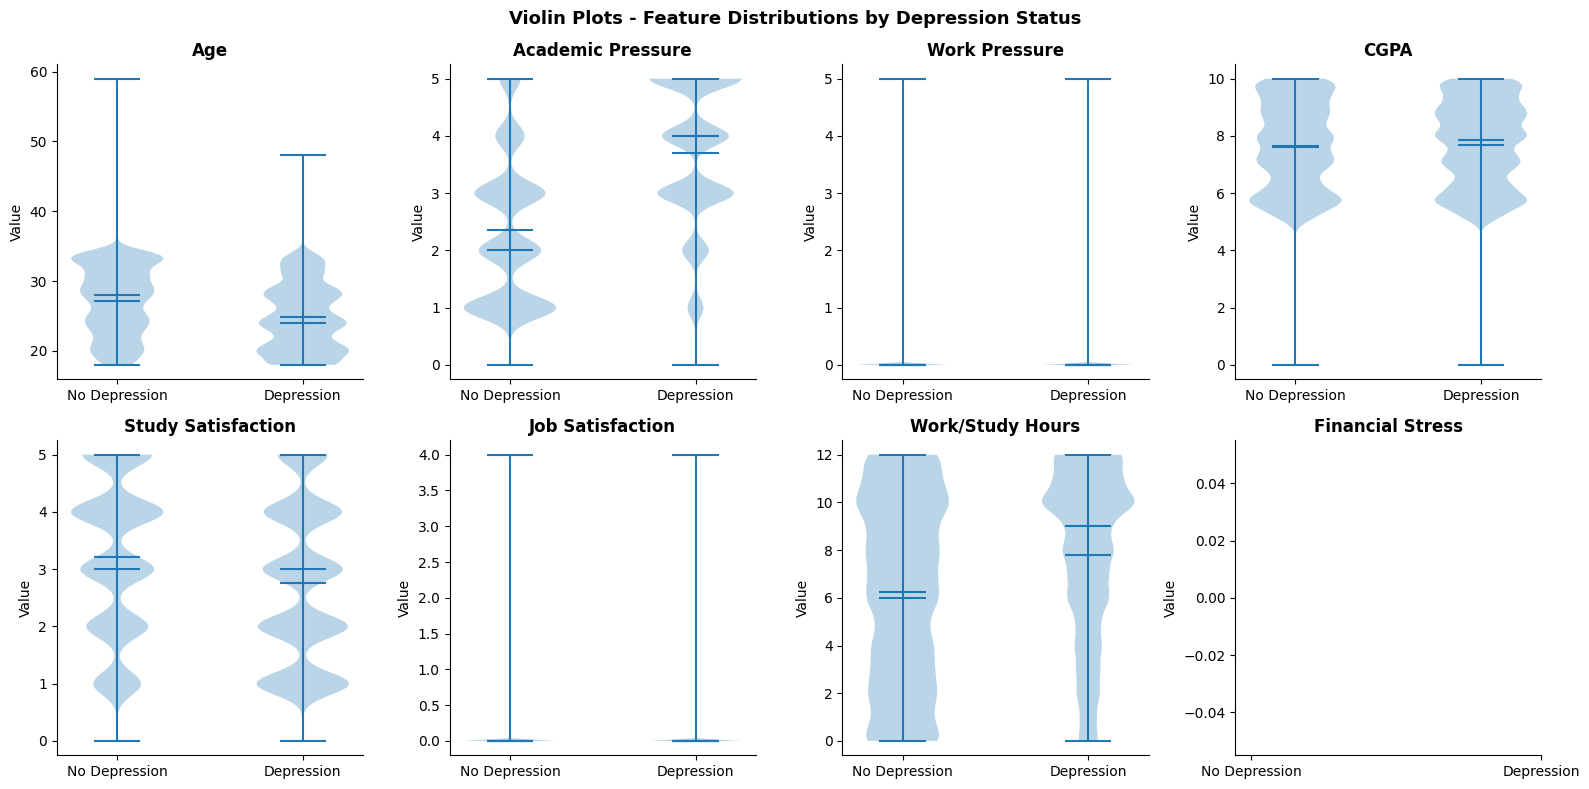

In [ ]:
# Statistical summary & violin plots
# Print mean/std/min/max for each numeric feature
# grouped by depression status.
# Then draw violin plots to visualise the full
# distribution shape for each group.

stat_summary = df_plot.groupby('Depression_Label')[numeric_features].agg(['mean', 'std', 'min', 'max'])

print('Statistical Summary by Depression Status:')
display(stat_summary.round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    ax = axes[idx]
    depression_group = df_plot[df_plot['Depression_Label'] == 'Depression'][col]
    no_depression_group = df_plot[df_plot['Depression_Label'] == 'No Depression'][col]
    
    data_to_plot = [no_depression_group, depression_group]
    bp = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Depression', 'Depression'])
    ax.set_ylabel('Value')
    ax.set_title(col, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Violin Plots - Feature Distributions by Depression Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()